# Correlation

**What is Correlation?**
Correlation measures the strength and direction of the
relationship between two numerical variables.

**Range:**
Correlation coefficient (r) ranges from -1 to +1

- r = +1   → Perfect Positive Correlation
- r = 0    → No Correlation
- r = -1   → Perfect Negative Correlation

**Types of Correlation:**
- Positive Correlation → Both variables increase together
- Negative Correlation → One increases, other decreases
- No Correlation       → No relationship between variables

**Types of Correlation Tests:**
- Pearson Correlation  → For linear relationship between numeric variables
- Spearman Correlation → For ranked/ordinal data or non-linear monotonic relationship

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr

## 1. Theory

**Pearson Correlation Formula:**
r = Σ[(x - x̄)(y - ȳ)] / √[Σ(x - x̄)² × Σ(y - ȳ)²]

**Interpreting Strength of r:**

- Value of r        | Strength            |

- 0.00 - 0.19        | Very Weak           |
- 0.20 - 0.39        | Weak                 |
- 0.40 - 0.59        | Moderate             |
- 0.60 - 0.79        | Strong               |
- 0.80 - 1.00        | Very Strong          |

**Hypothesis (for significance testing):**
- H0 → No correlation exists (r = 0)
- H1 → Correlation exists (r ≠ 0)

**Decision Rule:**
- If p-value < 0.05 → Reject H0 → Correlation is statistically significant
- If p-value > 0.05 → Accept H0 → Correlation is NOT statistically significant

## Dataset

A simple dataset of 10 people showing their
**Hours of Exercise per Week** and their
**Body Fat Percentage**.

Easy to guess the relationship just by looking at it.

In [ ]:
data = {
    "Person"          : [f"P{i+1}" for i in range(10)],
    "Exercise_Hours"   : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    "Body_Fat_Percent" : [28, 26, 25, 23, 21, 19, 18, 16, 14, 12]
}

df = pd.DataFrame(data)
print(df)

  Person  Exercise_Hours  Body_Fat_Percent
0     P1               1                28
1     P2               2                26
2     P3               3                25
3     P4               4                23
4     P5               5                21
5     P6               6                19
6     P7               7                18
7     P8               8                16
8     P9               9                14
9    P10              10                12


## 2. Pearson Correlation

**Question:**
Is there a relationship between Exercise Hours
and Body Fat Percentage?

**H0:** No correlation between Exercise Hours and Body Fat %
**H1:** Correlation exists between Exercise Hours and Body Fat %

In [ ]:
r_value, p_value = pearsonr(df["Exercise_Hours"], df["Body_Fat_Percent"])
print(r_value, p_value)

-0.9985288177497438 2.0458653407734143e-11


In [ ]:
x = df["Exercise_Hours"]
y = df["Body_Fat_Percent"]

x_mean = x.mean()
y_mean = y.mean()

numerator   = sum((x - x_mean) * (y - y_mean))
denominator = np.sqrt(sum((x - x_mean)**2) * sum((y - y_mean)**2))

manual_r = numerator / denominator

print(f"Mean of X (Exercise Hours) : {x_mean}")
print(f"Mean of Y (Body Fat %) : {y_mean}")
print(f"Numerator : {numerator:.2f}")
print(f"Denominator : {denominator:.2f}")
print(f"\nManual Pearson r : {manual_r:.4f}")
print(f"Scipy Pearson r : {r_value:.4f}")

Mean of X (Exercise Hours) : 5.5
Mean of Y (Body Fat %) : 20.2
Numerator : -145.00
Denominator : 145.21

Manual Pearson r : -0.9985
Scipy Pearson r : -0.9985


In [ ]:
alpha = 0.05

print(f"Result")
print(f"Correlation (r) : {r_value:.4f}")
print(f"P-Value          : {p_value:.6f}")

if p_value < alpha:
    print(f"\nP-Value {p_value:.6f} < {alpha}")
    print("Reject H0 ✅ → Correlation is statistically significant")
else:
    print(f"\nP-Value {p_value:.6f} > {alpha}")
    print("Accept H0 ✅ → Correlation is NOT statistically significant")

print(f"\n Interpreting Strength")
abs_r = abs(r_value)
if abs_r < 0.20:
    strength = "Very Weak"
elif abs_r < 0.40:
    strength = "Weak"
elif abs_r < 0.60:
    strength = "Moderate"
elif abs_r < 0.80:
    strength = "Strong"
else:
    strength = "Very Strong"

direction = "Negative" if r_value < 0 else "Positive"
print(f"This is a {strength} {direction} Correlation")

Result
Correlation (r) : -0.9985
P-Value          : 0.000000

P-Value 0.000000 < 0.05
Reject H0 ✅ → Correlation is statistically significant

 Interpreting Strength
This is a Very Strong Negative Correlation


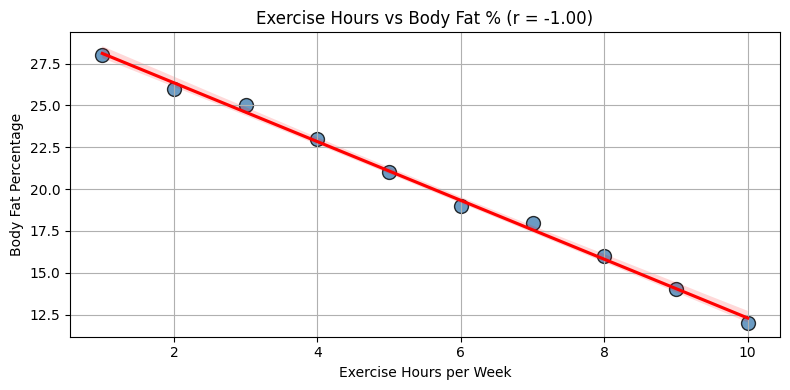

In [ ]:
plt.figure(figsize=(8, 4))

sns.regplot(data=df, x="Exercise_Hours", y="Body_Fat_Percent",
            color="steelblue", scatter_kws={"s": 100, "edgecolor": "black"},
            line_kws={"color": "red"})

plt.title(f"Exercise Hours vs Body Fat % (r = {r_value:.2f})")
plt.xlabel("Exercise Hours per Week")
plt.ylabel("Body Fat Percentage")
plt.grid(True)
plt.tight_layout()
plt.show()

## 3. Spearman Correlation

Used when data is ranked/ordinal, or when the
relationship is monotonic but not necessarily linear.

**Question:**
Same dataset — checking using rank-based correlation.

In [ ]:
spearman_r, spearman_p = spearmanr(df["Exercise_Hours"], df["Body_Fat_Percent"])

print(f"Spearman Correlation (r) : {spearman_r:.4f}")
print(f"P-Value                   : {spearman_p:.4f}")

print(f"\nPearson r  : {r_value:.4f}")
print(f"Spearman r : {spearman_r:.4f}")
print("\nBoth are close here because the relationship is linear.")

Spearman Correlation (r) : -1.0000
P-Value                   : 0.0000

Pearson r  : -0.9985
Spearman r : -1.0000

Both are close here because the relationship is linear.


## 4. Example of No Correlation

To understand r = 0, let's check a variable that has
no real relationship with Exercise Hours —
like Shoe Size (random, unrelated data).

In [ ]:
df["Shoe_Size"] = [7, 9, 6, 10, 8, 7, 9, 6, 10, 8]   # random, unrelated

r_random, p_random = pearsonr(df["Exercise_Hours"], df["Shoe_Size"])

print(f"Correlation (Exercise vs Shoe Size) : {r_random:.4f}")
print(f"P-Value                              : {p_random:.4f}")

print(f"\n=== Result ===")
if p_random < 0.05:
    print("Reject H0 ✅ → Surprisingly significant (rare with random data)")
else:
    print("Accept H0 ✅ → No significant correlation (as expected)")

Correlation (Exercise vs Shoe Size) : 0.1477
P-Value                              : 0.6838

=== Result ===
Accept H0 ✅ → No significant correlation (as expected)


## 5. Correlation Matrix

When you have multiple numeric columns, a correlation
matrix shows relationships between all pairs at once.

                  Exercise_Hours  Body_Fat_Percent  Shoe_Size
Exercise_Hours              1.00             -1.00       0.15
Body_Fat_Percent           -1.00              1.00      -0.15
Shoe_Size                   0.15             -0.15       1.00


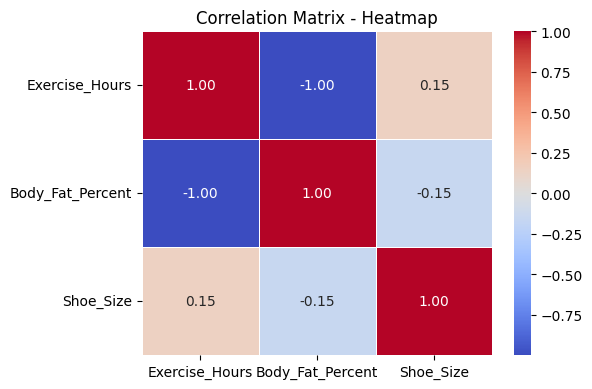

In [ ]:
corr_matrix = df[["Exercise_Hours", "Body_Fat_Percent", "Shoe_Size"]].corr()
print(corr_matrix.round(2))

plt.figure(figsize=(6, 4))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix - Heatmap")
plt.tight_layout()
plt.show()

## Conclusion

In this notebook I covered:

- What is Correlation and Types of Correlation
- Pearson Correlation (Self Made - Exercise vs Body Fat)
- Manual Pearson r Calculation
- Spearman Correlation
- Example of No Correlation (Shoe Size)
- Correlation Matrix & Heatmap
